# Adaptive real-time Prisoner's Dilemma analysis

This notebook reads the simulated export produced by `simulate_procedure.py` and summarizes dyad-level treatment assignment, final-round `(Cooperate, Cooperate)` events, and active-inference score components.

In [1]:
import csv, json, statistics, zipfile
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 70
zip_path = Path('../simulated_data.zip')
with zipfile.ZipFile(zip_path) as zf:
    with zf.open('offline/simulated_dyads.csv') as f:
        rows = list(csv.DictReader(line.decode('utf-8') for line in f))
    with zf.open('offline/offline_adaptive_simulation.json') as f:
        records = json.loads(f.read().decode('utf-8'))['records']

len(rows), rows[0]


(80, {'dyad_index': '0', 'treatment': 'communication', 'final_round_both_cooperated': '1', 'final_round_cooperative_choices': '2', 'final_round_trials': '2', 'last_round_both_cooperate_rate': '1', 'selected_treatment': 'communication', 'expected_information_gain': '0.1931471805599453', 'expected_utility_probability_both_cooperate': '0.5', 'combined_score': '0.24314718055994528', 'gamma': '0.1'})

In [2]:
summary = {}
for treatment in sorted({row['treatment'] for row in rows}):
    selected = [row for row in rows if row['treatment'] == treatment]
    rates = [float(row['last_round_both_cooperate_rate']) for row in selected]
    summary[treatment] = {
        'n_dyads': len(selected),
        'mean_last_round_both_cooperate_rate': statistics.mean(rates),
    }
summary


{'communication': {'n_dyads': 70, 'mean_last_round_both_cooperate_rate': 0.5}, 'no_communication': {'n_dyads': 10, 'mean_last_round_both_cooperate_rate': 0.1}}

<Figure size 560x525 with 3 Axes>

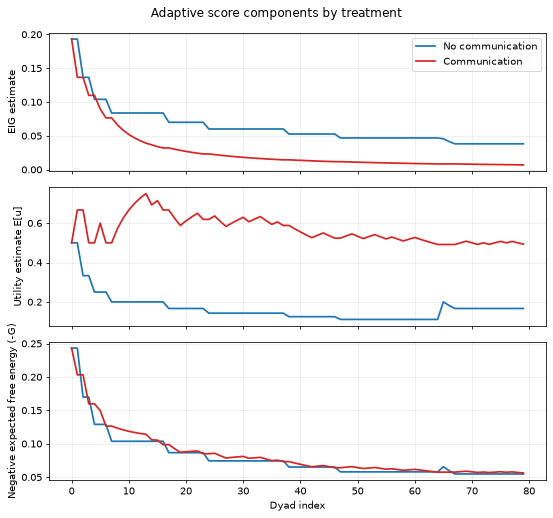

In [3]:
treatments = ['no_communication', 'communication']
labels = {'no_communication': 'No communication', 'communication': 'Communication'}
colors = {'no_communication': '#1f77b4', 'communication': '#d62728'}
metrics = [
    ('expected_information_gain', 'EIG estimate'),
    ('expected_utility_probability_both_cooperate', 'Utility estimate E[u]'),
    ('combined_score', 'Negative expected free energy (-G)'),
]

fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 7.5), sharex=True)
x = [record["dyad_index"] for record in records]
for ax, (metric, title) in zip(axes, metrics):
    for treatment in treatments:
        values = []
        for record in records:
            score = next(s for s in record["decision"]["candidate_scores"] if s["treatment"] == treatment)
            values.append(float(score[metric]))
        ax.plot(x, values, label=labels[treatment], color=colors[treatment], linewidth=1.8)
    ax.set_ylabel(title)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("Dyad index")
axes[0].legend(loc="best")
fig.suptitle("Adaptive score components by treatment")
fig.tight_layout()
fig


<Figure size 560x224 with 1 Axes>

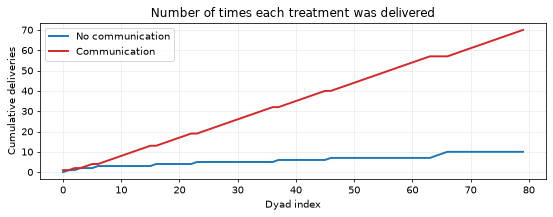

In [4]:
delivery_counts = {treatment: [] for treatment in treatments}
running = {treatment: 0 for treatment in treatments}
for record in records:
    running[record['treatment']] += 1
    for treatment in treatments:
        delivery_counts[treatment].append(running[treatment])

fig, ax = plt.subplots(figsize=(8, 3.2))
for treatment in treatments:
    ax.plot(x, delivery_counts[treatment], label=labels[treatment], color=colors[treatment], linewidth=2)
ax.set_xlabel('Dyad index')
ax.set_ylabel('Cumulative deliveries')
ax.set_title('Number of times each treatment was delivered')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
fig

The simulation is a workflow check, not evidence about human behavior. It verifies that dyad-level treatment assignment records EIG, expected utility `E[u]`, gamma, `-G`, cumulative treatment deliveries, and the final-round `(Cooperate, Cooperate)` outcome used by the adaptive policy.